# Multi-variable Linear Regression with Feature Scaling

**Goal:** Predict housing prices using multiple features.  
- Implement gradient descent for multiple variables from scratch  
- Explore the effect of learning rate on convergence  
- Use Z-score normalization to scale features for faster convergence  
- Predict prices for new houses  

**Features:**  
1. Size (sqft)  
2. Number of bedrooms  
3. Number of floors  
4. Age of home  

**Target:** House price (in $1000s)  

This notebook is beginner-friendly, fully commented, and easy to revisit for concept review.

In [18]:
# !pip install seaborn

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # applies seaborn style globally



## Load the Housing Dataset

We use a small example dataset of houses with 4 features:
- Size (sqft)
- Bedrooms
- Floors
- Age

Target variable: Price in 1000s dollars

We'll visualize each feature vs the price to see how features influence it.

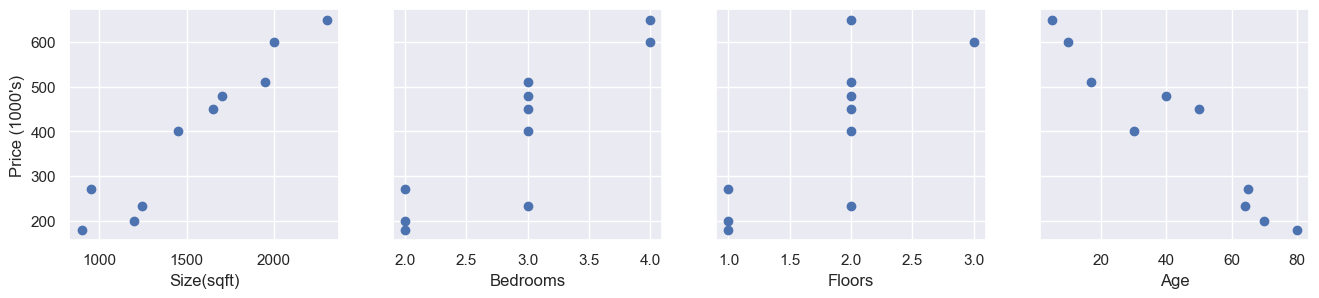

In [20]:
# Sample dataset: 10 houses
X_train = np.array([
    [952, 2, 1, 65],
    [1244, 3, 2, 64],
    [1947, 3, 2, 17],
    [2000, 4, 3, 10],
    [1650, 3, 2, 50],
    [1200, 2, 1, 70],
    [2300, 4, 2, 5],
    [900, 2, 1, 80],
    [1450, 3, 2, 30],
    [1700, 3, 2, 40]
])

y_train = np.array([271.5, 232, 509.8, 600, 450, 200, 650, 180, 400, 480])

X_features = ['Size(sqft)','Bedrooms','Floors','Age']

# Visualize each feature vs price
fig, ax = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

## Gradient Descent for Multiple Variables

We want to minimize the cost function:

J(w,b) = (1/2m) * Σ (prediction - y)^2

- **w**: weight vector for features  
- **b**: bias  
- **alpha**: learning rate  

Gradient Descent Updates:

w_j := w_j - alpha * dJ/dw_j  
b   := b - alpha * dJ/db  

We repeat until convergence.

In [21]:
def compute_cost_multi(X, y, w, b):
    m = X.shape[0]
    predictions = X.dot(w) + b
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

def run_gradient_descent(X, y, num_iters, alpha):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    cost_history = []

    for i in range(num_iters):
        predictions = X.dot(w) + b
        error = predictions - y

        # Compute gradients
        dw = (1/m) * X.T.dot(error)
        db = (1/m) * np.sum(error)

        # Update weights and bias
        w -= alpha * dw
        b -= alpha * db

        # Compute cost
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

    return w, b, cost_history

## Z-Score Normalization

We scale each feature to have:
- Mean = 0
- Standard Deviation = 1

Formula:

x_norm = (x - mean) / std

This ensures gradient descent converges faster.

In [22]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalize dataset
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print("Feature Means:", X_mu)
print("Feature Std Devs:", X_sigma)

Feature Means: [1534.3    2.9    1.8   43.1]
Feature Std Devs: [442.59   0.7    0.6   25.41]


We can visualize normalization in steps:
1. Original data  
2. Mean removed  
3. Z-score normalized

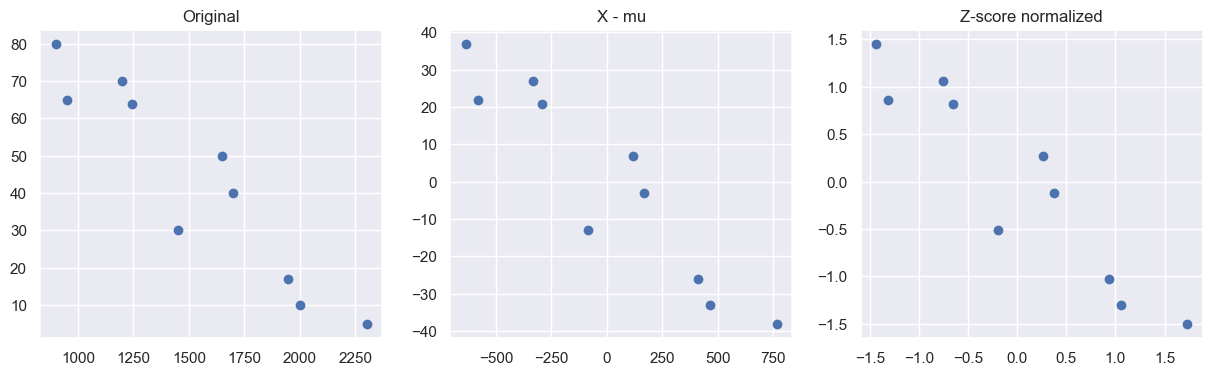

In [23]:
X_mean = X_train - X_mu

fig, ax = plt.subplots(1,3,figsize=(15,4))
ax[0].scatter(X_train[:,0], X_train[:,3]); ax[0].set_title("Original")
ax[1].scatter(X_mean[:,0], X_mean[:,3]); ax[1].set_title("X - mu")
ax[2].scatter(X_norm[:,0], X_norm[:,3]); ax[2].set_title("Z-score normalized")
plt.show()

Now we run gradient descent on the normalized features.  
We can use a **larger learning rate** because features are scaled similarly.

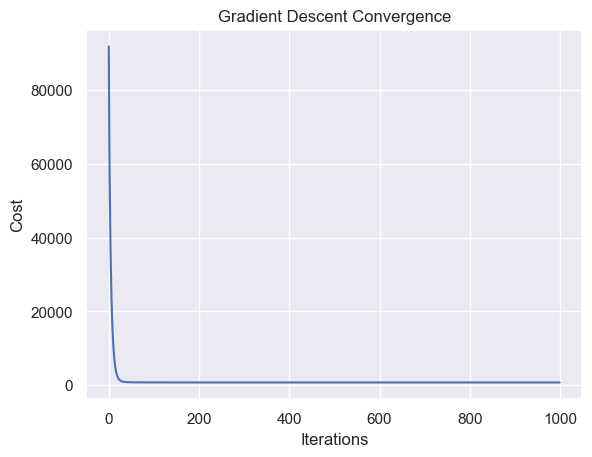

In [24]:
iterations = 1000
alpha = 0.1  # safe large learning rate after normalization

w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, iterations, alpha)

# Plot cost over iterations
plt.plot(hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()

Compare predicted prices vs actual target prices to see how well the model learned.

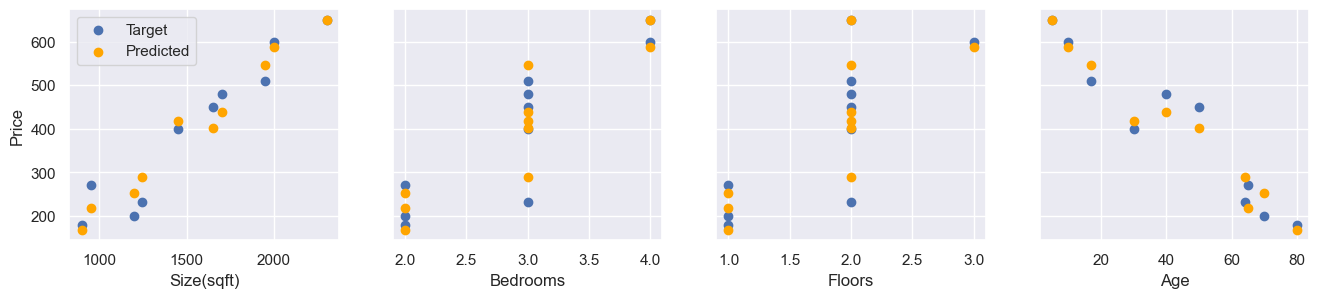

In [25]:
# Predict prices using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm

# Plot
fig, ax = plt.subplots(1,4,figsize=(16,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train, label='Target')
    ax[i].scatter(X_train[:,i], yp, color='orange', label='Predicted')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price")
ax[0].legend()
plt.show()

Now let's predict the price of a new house with the following features:
- 1200 sqft
- 3 bedrooms
- 1 floor
- 40 years old

In [26]:
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma

x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f"Predicted price = ${x_house_predict*1000:0.0f}")

Predicted price = $336835


### Key Learnings
- Implemented multi-variable linear regression from scratch  
- Explored gradient descent and learning rate effect  
- Applied Z-score normalization for faster convergence  
- Made predictions on unseen data  
- Visualized convergence and predictions  

This notebook is fully self-contained and easy to revisit to refresh concepts.